# Getting Started with GWMLT
---
---

## 1. Installation
---

It is strongly recommended to let `pixi` manage your virtual environment and dependencies. 

### Option A: Using Pixi (Recommended)
First, ensure you have [pixi](https://pixi.sh) and [direnv](https://direnv.net/) installed. Then follow these steps:

1. Navigate to the project directory and allow the environment:
   ```bash
   cd gwmlt
   direnv allow
   ```
2. Install TEOBResumS (Dali):
   ```bash
   pixi run install-teobresums
   ```
3. Run the test suite to ensure everything is working:
   ```bash
   pixi run tests
   ```

### Option B: Using pip

If you prefer to install `gwmlt` into your own existing environment, first make sure that you have `gcc` and `gsl` available, and then run the following commands:

1. Navigate to the project directory and install in editable mode:
   ```bash
   cd gwmlt
   pip install -e .
   ```
2. Install TEOBResumS (Dali):
   ```bash
   bash scripts/install_teobresums.sh
   ```
3. Install pytest and run the test suite:
   ```bash
   pip install pytest
   pytest -v
   ```

\
**Note:** The first time the tests are run, the Julia dependencies will be automatically downloaded and compiled in the background. This may take a few minutes.

## 2. The core dataclasses
---

The code is organized around three core dataclasses which are used to represent :
1. The binary system parameters (both intrinsic and extrinsic)
2. The kind of waveform you want to generate (like eccentric or microlensed)
3. The kind of detectors you want to use (ground based or space based, and with which PSD)

All three are available under the `gwmlt.core` module.

### 2.1 The BBHSystem dataclass :

This is used to create an instance of the dataclass representing a binary black hole system.\
You can also add a BNS system or a NSBH system if needed by inheriting from the parent `BinarySystem` class.

Here are a few things you can do with this dataclass :

In [29]:
import numpy as np
from rich import print

In [30]:
from gwmlt.core import BBHSystem
from gwmlt.core import LFrameSpins, JFrameSpins

In [31]:
# Let's construct a BBH system :

print(

    BBHSystem(
        mass_1 = 15.0, 
        mass_2 = 25.0,
        geocent_time = 1e5,
        luminosity_distance = 500.0,

        # The spins are defined with their own dataclass
        # If the J frame spins are provided, the L frame spins will automatically be computed, and vice versa.
        spins = JFrameSpins(
            a_1 = 0.5, 
            a_2 = 0.25, 
            tilt_1 = np.pi/2
            # All the rest will default to zero.
        )
    )
    
)

BBHSystem(
    mass_1=15.0,
    mass_2=25.0,
    ra=0.0,
    dec=0.0,
    phase=0.0,
    psi=0.0,
    geocent_time=LIGOTimeGPS(100000, 0),
    luminosity_distance=500.0,
    j_frame=JFrameSpins(
        a_1=0.5,
        a_2=0.25,
        tilt_1=1.5707963267948966,
        tilt_2=0.0,
        phi_12=0.0,
        phi_jl=0.0,
        theta_jn=0.0
    ),
    l_frame=LFrameSpins(
        inclination=0.05880755437623463,
        spin1x=-3.061616997868383e-17,
        spin1y=0.5,
        spin1z=3.122502256758253e-17,
        spin2x=0.0,
        spin2y=0.0,
        spin2z=0.25
    )
)

In [32]:
# Or we can define the system with chirp mass or total mass also
source = BBHSystem.from_mchirp(
    mchirp = 20.0, 
    q = 0.5,
    spins = LFrameSpins(spin1x=0.5, spin2y=-0.25)
)

print(source)

# And we can get various properties of the system like the chirp mass, chi_eff, chi_p etc.
print(f"Chirp mass : {source.mchirp}, chi_eff : {source.chi_eff}, chi_p : {source.chi_p}")

BBHSystem(
    mass_1=32.875036590344514,
    mass_2=16.437518295172257,
    ra=0.0,
    dec=0.0,
    phase=0.0,
    psi=0.0,
    geocent_time=LIGOTimeGPS(0, 0),
    luminosity_distance=100.0,
    j_frame=JFrameSpins(
        a_1=0.5,
        a_2=0.25,
        tilt_1=1.5707963267948966,
        tilt_2=1.5707963267948966,
        phi_12=4.71238898038469,
        phi_jl=1.5707963267948968,
        theta_jn=0.224526742357635
    ),
    l_frame=LFrameSpins(
        inclination=0.0,
        spin1x=0.5,
        spin1y=0.0,
        spin1z=0.0,
        spin2x=0.0,
        spin2y=-0.25,
        spin2z=0.0
    )
)

Chirp mass : 19.999999999999996, chi_eff : 0.0, chi_p : 0.5

### 2.2 The Morphology dataclasses :

The morphology dataclasses (e.g. Quasicircular, Eccentric, Lensed) are used to specify the kind of waveform you would like to generate. 

Each of them need their own set of parameters. For example, the Eccentric dataclass needs the eccentricity and the mean anomaly.

In [33]:
from gwmlt.core import Eccentric, Quasicircular, Lensed

In [34]:
print(Quasicircular())
print(Eccentric(eccentricity=0.1, anomaly=1.0))
print(Lensed(m_lens=1e4, y_lens=0.5)) 

Quasicircular(wf_approximant='IMRPhenomXO4a', allow_precession=False)

Eccentric(wf_approximant='teobresums', allow_precession=False, eccentricity=0.1, anomaly=1.0)

Lensed(wf_approximant='IMRPhenomXO4a', allow_precession=False, m_lens=10000.0, y_lens=0.5, z_lens=0.0)

### 2.3 The Observatory dataclasses :

Observatories are just a network of detectors for a given noise or PSD profile.\
There are two broad categories of observatories : ground based and space based.

In [35]:
from gwmlt.core import GroundBased, Decihertz

In [36]:
observatory = GroundBased(noise_psds='O4_gaus', detector_list=['H1', 'V1'])

print(observatory)
print(f'Active detectors: {observatory.active_detectors}')

GroundBased(
    noise_psds='O4_gaus',
    detector_list=['H1', 'V1'],
    f_low=20.0,
    sample_rate=4096.0,
    wf_gen_srate=4096.0,
    resolved_paths={
        'H1': 
PosixPath('/home/sparsha.ray/workspace/gwmlt/src/gwmlt/data/noise/detector_PSDs/aLIGO_O4_high_psd.npz'),
        'V1': 
PosixPath('/home/sparsha.ray/workspace/gwmlt/src/gwmlt/data/noise/detector_PSDs/aVirgo_O4_high_psd.npz')
    }
)

Active detectors: ['H1', 'V1']

In [37]:
print(Decihertz(wf_duration=100, noise_psds='S2_gaus'))

Decihertz(
    noise_psds='S2_gaus',
    detector_list=None,
    f_low=1.0,
    sample_rate=20.0,
    wf_gen_srate=2560.0,
    resolved_paths={
        'IndIGO-D': 
PosixPath('/home/sparsha.ray/workspace/gwmlt/src/gwmlt/data/noise/detector_PSDs/IndIGO-D_S2_psd.npz')
    },
    wf_duration=100,
    ecc_f_ref=20.0
)

## 3. Generating the waveforms
---

Now let's generate the h_plus and h_cross waveforms for a given binary system, morphology and observatory :

In [38]:
source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    geocent_time = 1e5,
    luminosity_distance = 500.0
)

morphology = Eccentric(eccentricity=0.25)

observatory = GroundBased(noise_psds='O4_gaus')

In [39]:
from gwmlt.waveform import generate_waveform

hp, hc, params = generate_waveform(source, morphology, observatory)

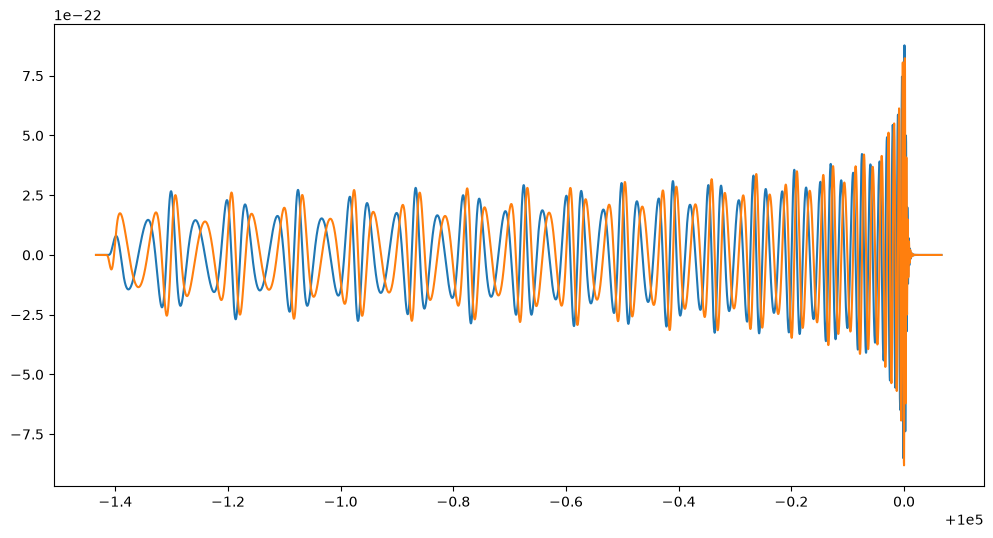

The complete parameters dictionary which was used to generate the waveform : {'mass1': 15.0, 'mass2': 25.0, 
'lambda1': 0.0, 'lambda2': 0.0, 'spin1x': 0.0, 'spin1y': 0.0, 'spin1z': 0.0, 'spin2x': 0.0, 'spin2y': 0.0, 
'spin2z': 0.0, 'inclination': 0.0, 'coa_phase': 0.0, 'distance': 500.0, 'f_lower': 20.0, 'ecc': 0.25, 'anomaly': 
0.0, 'approximant': 'teobresums', 'delta_t': 0.000244140625, 'use_mode_lm': [1], 'ecc_freq': 3}

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
hp.plot()
hc.plot()
plt.show()

print(f'The complete parameters dictionary which was used to generate the waveform : {params}')

For space based detectors, we specify the waveform duration instead, the initial conditions are automatically calculated :

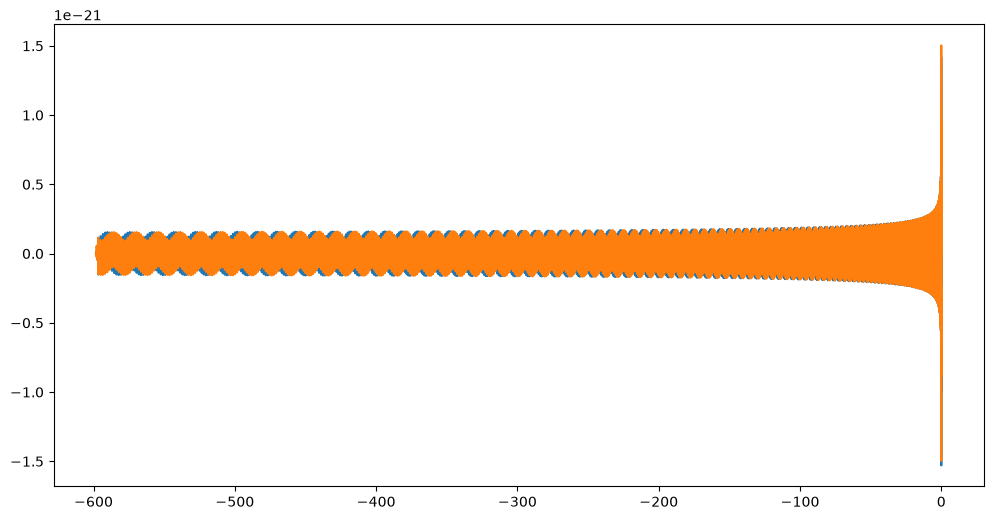

{
    'mass1': 25.0,
    'mass2': 45.0,
    'lambda1': 0.0,
    'lambda2': 0.0,
    'spin1x': 0.0,
    'spin1y': 0.0,
    'spin1z': 0.0,
    'spin2x': 0.0,
    'spin2y': 0.0,
    'spin2z': 0.0,
    'inclination': 0.0,
    'coa_phase': 0.0,
    'distance': 500.0,
    'f_lower': 1.2761285726934986,
    'ecc': 0.42755981099486434,
    'anomaly': 0.0,
    'approximant': 'teobresums',
    'delta_t': 0.000390625,
    'use_mode_lm': [1],
    'ecc_freq': 3
}

In [41]:
source = BBHSystem(
    mass_1 = 25.0,
    mass_2 = 45.0,
    geocent_time = 0.0,
    luminosity_distance = 500.0
)
morphology = Eccentric(eccentricity=0.1)
observatory = Decihertz(wf_duration=600, ecc_f_ref=7.5, noise_psds='S2_gaus')

hp, hc, params = generate_waveform(source, morphology, observatory)

plt.figure(figsize=(12, 6))
hp.plot()
hc.plot()
plt.show()

print(params)

## 4. Imparting lensing effects
---

Calculating the frequency dependent amplification factors is computationally expensive and is usually quite slow.\
However a few amazing Julia packages in the backend makes it much faster :

In [42]:
from gwmlt.lensing.pointlens import Ff_hybrid

In [43]:
# Julia compiles in the first run, so the second time's the charm
%timeit Ff_hybrid(np.geomspace(0.01, 100, 100_000), 1e4, 0.5)

74.8 ms ± 5.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


And here's how the amplification factor looks like as a function of frequency :

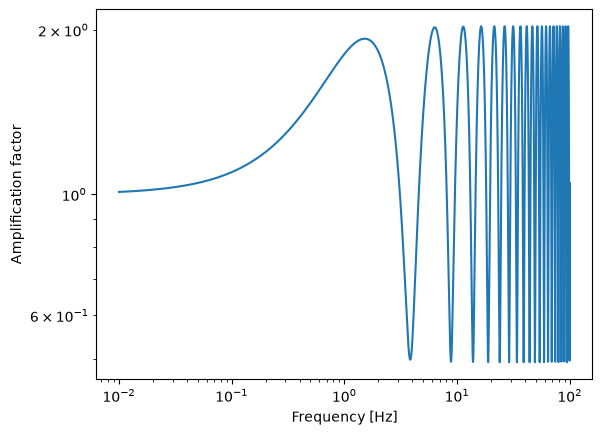

In [44]:
f_arr = np.geomspace(0.01, 100, 10000)
plt.plot(f_arr, np.abs(Ff_hybrid(f_arr, 1e4, 0.5)))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplification factor')
plt.loglog()
plt.show()

Lets see how the waveform looks like after lensing amplification is applied :

In [45]:
source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    geocent_time = 0.0,
    luminosity_distance = 500.0
)
morphology = Lensed(m_lens=1e4, y_lens=0.5)
observatory = GroundBased(noise_psds='O4_gaus')

hp, hc, params = generate_waveform(source, morphology, observatory)

Time delay due to lensing : 0.19905962234933322 seconds

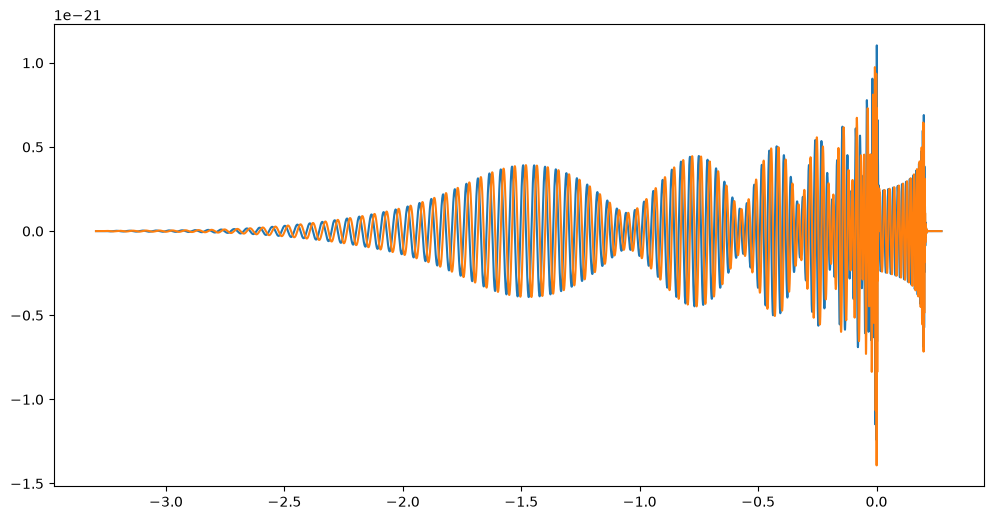

In [46]:
from gwmlt.lensing import apply_lensing

hp_lensed, hc_lensed, lensing_td = apply_lensing(hp, hc, morphology.m_lens, morphology.y_lens)

plt.figure(figsize=(12, 6))
hp_lensed.plot()
hc_lensed.plot()
plt.plot()

print(f'Time delay due to lensing : {lensing_td} seconds')

## 5. Projection to get strain
---

Now that we have the lensed polarizations, we have to project them onto the detectors to get the strains :

In [47]:
from gwmlt.waveform.projector import project_waveform

{
    'H1': (<pycbc.types.timeseries.TimeSeries object at 0x7fe65086d4e0>, np.float64(-0.014199768364038488)),
    'L1': (<pycbc.types.timeseries.TimeSeries object at 0x7fe6508e7310>, np.float64(-0.017799036978399067)),
    'V1': (<pycbc.types.timeseries.TimeSeries object at 0x7fe6508e6890>, np.float64(0.006559773616353256))
}

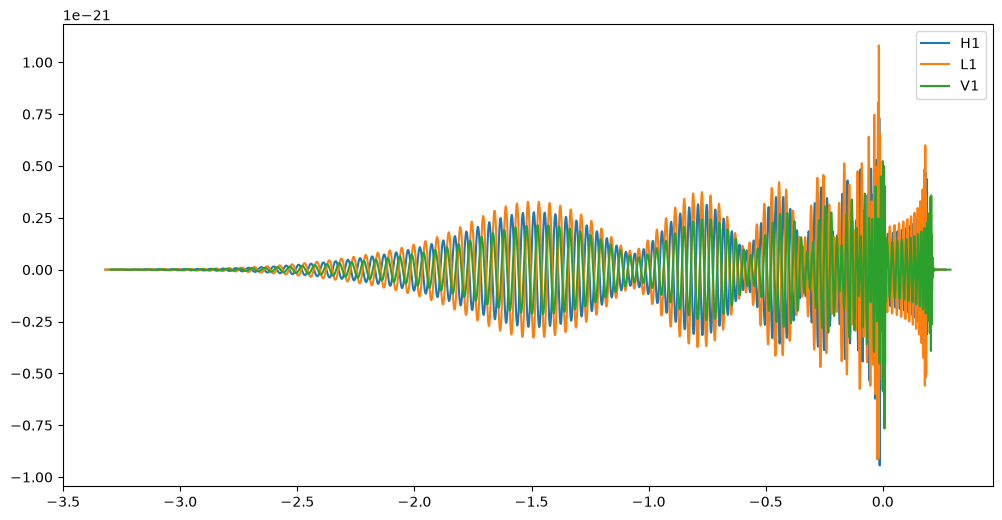

In [48]:
res = project_waveform(hp_lensed, hc_lensed, source.ra, source.dec, source.psi, observatory)
# After projecting we get strains in the detectors and their corresponding time delay from earth center
print(res)

plt.figure(figsize=(12, 6))
for detector, (strain, td) in res.items() :
    strain.plot(label=detector)
plt.legend()
plt.show()

## 6. Injection into noise
---

And finally we can inject the strains into the noise :

54.02001362869807

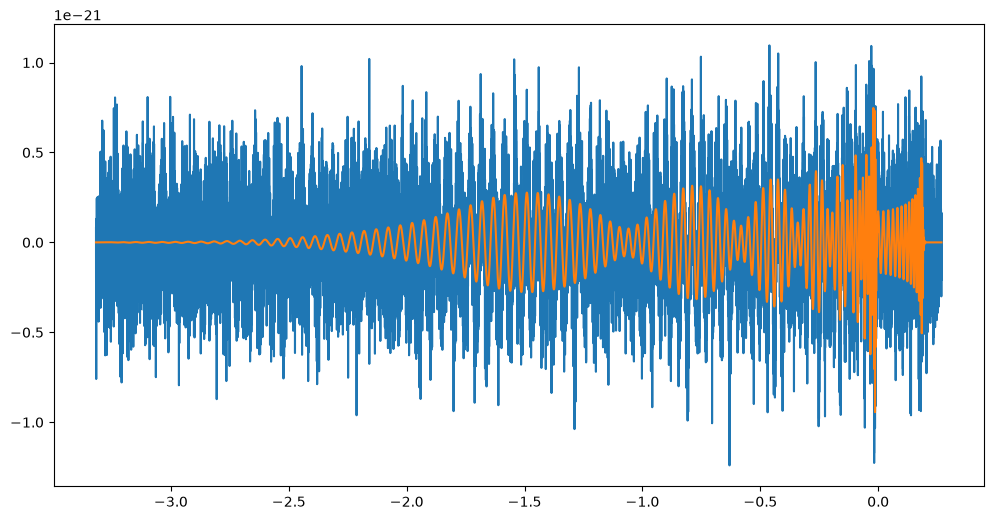

In [49]:
from gwmlt.noise.inject import inject_noise

det = 'H1'
noise_file_path = observatory.resolved_paths[det]

noisy_sig, clean_sig, snr = inject_noise(res[det][0], noise_file_path, f_low=20.0)
print(snr)

plt.figure(figsize=(12, 6))
noisy_sig.plot()
clean_sig.plot()
plt.show()

## 7. The pipeline
---

Instead of having to do all the steps manually, we can also use the top level injection wrapper.\
This automatically crops and pads the signals for us, and calculates the network optimal SNR.\
Here are a few examples of how the end to end usage looks like :

In [50]:
# Import the core dataclasses and functions

from gwmlt.core import BBHSystem, JFrameSpins
from gwmlt.core import Quasicircular, Eccentric, Lensed
from gwmlt.core import GroundBased, Decihertz

from gwmlt.pipeline import generate_injections

InjectionResult(
    injections={
        'H1': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe64f74c130>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe65086c7c0>,
            geocenter_td=np.float64(-0.011330504243174387),
            snr=67.2025450353401,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe65086eb30>
        ),
        'L1': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe67064b380>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe65086e900>,
            geocenter_td=np.float64(-0.016846364013896227),
            snr=95.02764129821874,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe65086c670>
        ),
        'V1': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe8c439e4a0>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe67076bd20>,
            geocenter_td=np.float64(-0.014200157208371427),
            snr=81.952749490495,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe65086d390>
        )
    },
    network_snr=np.float64(142.34706817838457),
    lensing_td=np.float64(0.19905962234933322),
    geocent_time=LIGOTimeGPS(0, 0),
    gen_pars={
        'mass1': 15.0,
        'mass2': 25.0,
        'lambda1': 0.0,
        'lambda2': 0.0,
        'spin1x': 0.0,
        'spin1y': 0.0,
        'spin1z': 0.3535533905932738,
        'spin2x': 0.0,
        'spin2y': 0.0,
        'spin2z': 0.25,
        'inclination': 0.03994607329926231,
        'coa_phase': 0.25,
        'distance': 500.0,
        'f_lower': 20.0,
        'approximant': 'IMRPhenomXO4a',
        'delta_t': 0.000244140625,
        'mode_array': None,
        'f_ref': 20.0
    },
    _pre_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe65086ec10>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe64f74ca60>
    ),
    _post_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe65086e580>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe65086d1d0>
    )
)

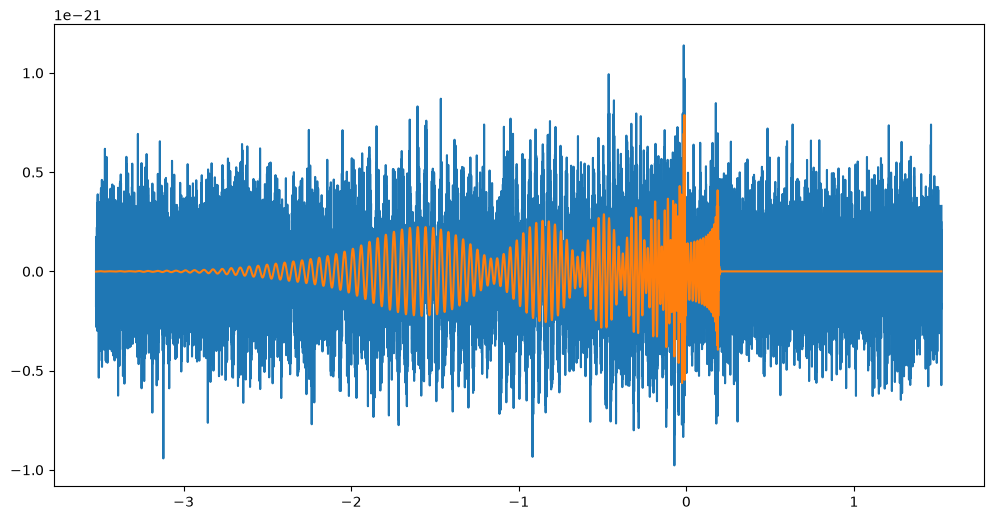

In [51]:
# Ground based detectors, synthetic colored gaussian noise

source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    ra = 1.0,
    dec = 0.5,
    phase = 0.25,
    psi = 1.5,
    geocent_time = 0.0,
    luminosity_distance = 500.0,
    spins = JFrameSpins(a_1=0.5, a_2=0.25, tilt_1=np.pi/4)
)

morphology = Lensed(m_lens=1e4, y_lens=0.5)
observatory = GroundBased(noise_psds='O5b_gaus')


res = generate_injections(source, morphology, observatory, seed=42)
print(res)

plt.figure(figsize=(12, 6))
res.injections['H1'].noisy_strain.plot()
res.injections['H1'].clean_strain.plot()
plt.show()

InjectionResult(
    injections={
        'H1': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe6507f0f30>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe6507f09f0>,
            geocenter_td=np.float64(-0.011330504243174387),
            snr=33.91442967277432,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe6507f2120>
        ),
        'L1': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe650a6c210>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe64f022d60>,
            geocenter_td=np.float64(-0.016846364013896227),
            snr=49.04621286237162,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe6507f1a20>
        )
    },
    network_snr=np.float64(59.6298544033995),
    lensing_td=np.float64(0.19905962234933322),
    geocent_time=LIGOTimeGPS(0, 0),
    gen_pars={
        'mass1': 15.0,
        'mass2': 25.0,
        'lambda1': 0.0,
        'lambda2': 0.0,
        'spin1x': 0.0,
        'spin1y': 0.0,
        'spin1z': 0.3535533905932738,
        'spin2x': 0.0,
        'spin2y': 0.0,
        'spin2z': 0.25,
        'inclination': 0.03994607329926231,
        'coa_phase': 0.25,
        'distance': 500.0,
        'f_lower': 20.0,
        'approximant': 'IMRPhenomXO4a',
        'delta_t': 0.000244140625,
        'mode_array': None,
        'f_ref': 20.0
    },
    _pre_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe6508e7620>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe650a6fe00>
    ),
    _post_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe64f022c80>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe64f022a50>
    )
)

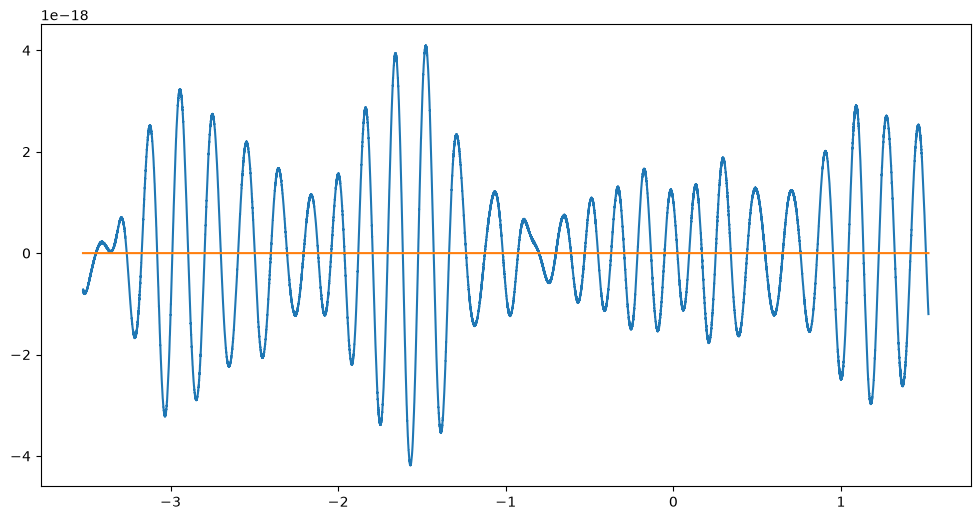

In [52]:
# Ground based detectors, real noise

source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    ra = 1.0,
    dec = 0.5,
    phase = 0.25,
    psi = 1.5,
    geocent_time = 0.0,
    luminosity_distance = 500.0,
    spins = JFrameSpins(a_1=0.5, a_2=0.25, tilt_1=np.pi/4)
)

morphology = Lensed(m_lens=1e4, y_lens=0.5)
observatory = GroundBased(noise_psds='O4_real')


res = generate_injections(source, morphology, observatory, seed=42)
print(res)

plt.figure(figsize=(12, 6))
res.injections['H1'].noisy_strain.plot()
res.injections['H1'].clean_strain.plot()
plt.show()

/home/sparsha.ray/workspace/gwmlt/src/gwmlt/pipeline/injection.py:139: UserWarning: Observatory waveform duration (600 s) is less than the minimum required duration (1067 s) for the current injection configuration.
This may lead to unintended truncations. Consider increasing the observatory's `wf_duration`.
  warnings.warn(


InjectionResult(
    injections={
        'IndIGO-D': DetectorInjection(
            noisy_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe64f0208a0>,
            clean_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe63b488440>,
            geocenter_td=np.float64(130.47204749110833),
            snr=11.40448048131705,
            _projected_strain=<pycbc.types.timeseries.TimeSeries object at 0x7fe64f0223c0>
        )
    },
    network_snr=np.float64(11.40448048131705),
    lensing_td=None,
    geocent_time=LIGOTimeGPS(0, 0),
    gen_pars={
        'mass1': 15.0,
        'mass2': 25.0,
        'lambda1': 0.0,
        'lambda2': 0.0,
        'spin1x': 0.0,
        'spin1y': 0.0,
        'spin1z': 0.3535533905932738,
        'spin2x': 0.0,
        'spin2y': 0.0,
        'spin2z': 0.25,
        'inclination': 0.03994607329926231,
        'coa_phase': 0.25,
        'distance': 500.0,
        'f_lower': 2.0592685276365046,
        'ecc': 0.3146161329125855,
        'anomaly': 1.0,
        'approximant': 'teobresums',
        'delta_t': 0.000390625,
        'use_mode_lm': [1],
        'ecc_freq': 3
    },
    _pre_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe6507f2350>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe6508e7d20>
    ),
    _post_lens_pols=(
        <pycbc.types.timeseries.TimeSeries object at 0x7fe6508e7e00>,
        <pycbc.types.timeseries.TimeSeries object at 0x7fe64f020d70>
    )
)

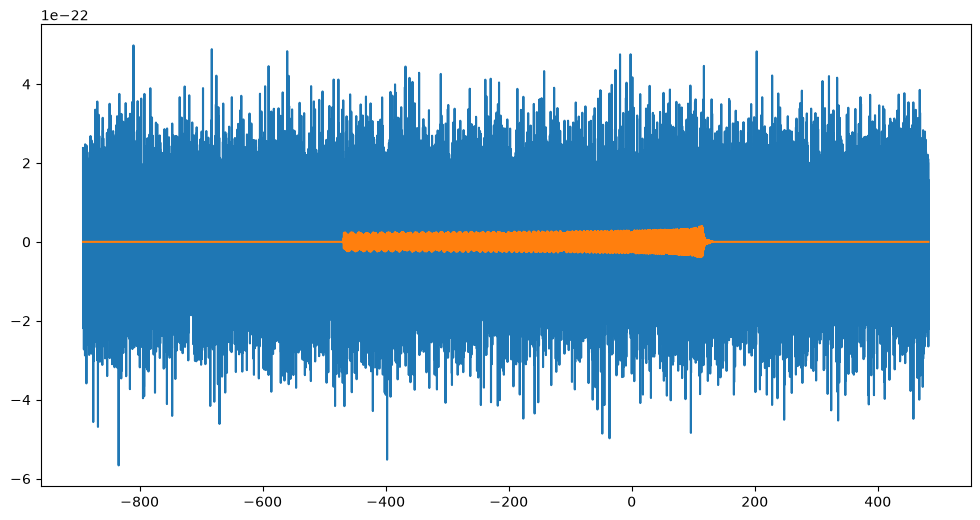

In [53]:
# Space based detector, synthetic colored gaussian noise

source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    ra = 1.0,
    dec = 0.5,
    phase = 0.25,
    psi = 1.5,
    geocent_time = 0.0,
    luminosity_distance = 500.0,
    spins = JFrameSpins(a_1=0.5, a_2=0.25, tilt_1=np.pi/4)
)

morphology = Eccentric(eccentricity=0.1, anomaly=1.0)
observatory = Decihertz(wf_duration=600, ecc_f_ref=7.5, noise_psds='S2_gaus')


res = generate_injections(source, morphology, observatory, seed=42)
print(res)

plt.figure(figsize=(12, 6))
res.injections['IndIGO-D'].noisy_strain.plot()
res.injections['IndIGO-D'].clean_strain.plot()
plt.show()

## 8. Benchmarking the pipeline
---

In [54]:
from pyinstrument import Profiler

source = BBHSystem(
    mass_1 = 15.0,
    mass_2 = 25.0,
    ra = 1.0,
    dec = 0.5,
    phase = 0.25,
    psi = 1.5,
    geocent_time = 0.0,
    luminosity_distance = 500.0,
    spins = JFrameSpins(a_1=0.5, a_2=0.25, tilt_1=np.pi/4)
)

In [ ]:
# Lensed waveforms

profiler = Profiler()

morphology = Lensed(m_lens=1e4, y_lens=0.5)
observatory = Decihertz(wf_duration=600, ecc_f_ref=7.5, noise_psds='S2_gaus')

profiler.start()
generate_injections(source, morphology, observatory)
profiler.stop()

profiler.print(color=True, unicode=True, show_all=False, timeline=True)

# In case of lensed waveforms, as we can see in the profile reports below, the timeseries and frequencyseries interconversion, 
# downsampling to the observatory's sampling rate, and generation of noise are the most time consuming steps.
# So, if needed, the `wf_gen_srate` parameter of the observatory can be reduced further to speed up the pipeline.

/home/sparsha.ray/workspace/gwmlt/src/gwmlt/pipeline/injection.py:139: UserWarning: Observatory waveform duration (600 s) is less than the minimum required duration (1067 s) for the current injection configuration.
This may lead to unintended truncations. Consider increasing the observatory's `wf_duration`.
  warnings.warn(



  _     ._   __/__   _ _  _  _ _/_   Recorded: 04:52:50 AM Samples:  370
 /_//_/// /_\ / //_// / //_'/ //     Duration: 2.389     CPU time: 2.255
/   _/                      v5.1.2

Profile at /tmp/ipykernel_689196/4103800329.py:8

2.389 ZMQInteractiveShell.run_code  IPython/core/interactiveshell.py:3712
└─ 2.388 <module>  /tmp/ipykernel_689196/4103800329.py:1
   └─ 2.384 generate_injections  gwmlt/pipeline/injection.py:87
      ├─ 1.271 generate_waveform  gwmlt/waveform/generator.py:17
      │  ├─ 0.031 _get_pars  gwmlt/waveform/generator.py:65
      │  │  └─ 0.031 imrphenom_fillen_initconds  gwmlt/utils/waveform.py:108
      │  │     └─ 0.031 root_scalar  scipy/optimize/_root_scalar.py:62
      │  │        └─ 0.031 brentq  scipy/optimize/_zeros_py.py:724
      │  │           └─ 0.031 f_raise  scipy/optimize/_zeros_py.py:106
      │  │              └─ 0.031 waveform_duration_error  gwmlt/utils/waveform.py:145
      │  │                 └─ 0.031 get_waveform_filter_length_in_time  pyc

In [56]:
# Eccentric waveforms

profiler = Profiler()

morphology = Eccentric(eccentricity=0.1, anomaly=1.0)
observatory = Decihertz(wf_duration=600, ecc_f_ref=7.5, noise_psds='S2_gaus')

profiler.start()
generate_injections(source, morphology, observatory)
profiler.stop()

profiler.print(color=True, unicode=True, show_all=False, timeline=True)

# For the eccentric waveforms however, the waveform generation itself is the most time consuming step, and can not be sped up further.


  _     ._   __/__   _ _  _  _ _/_   Recorded: 04:52:53 AM Samples:  417
 /_//_/// /_\ / //_// / //_'/ //     Duration: 14.384    CPU time: 26.983
/   _/                      v5.1.2

Profile at /tmp/ipykernel_689196/4168102785.py:8

14.383 ZMQInteractiveShell.run_ast_nodes  IPython/core/interactiveshell.py:3589
└─ 14.383 <module>  /tmp/ipykernel_689196/4168102785.py:1
   └─ 14.379 generate_injections  gwmlt/pipeline/injection.py:87
      ├─ 13.808 generate_waveform  gwmlt/waveform/generator.py:17
      │  ├─ 0.245 _get_pars  gwmlt/waveform/generator.py:65
      │  │  └─ 0.245 teobresumsfits_generalized_initconds  gwmlt/eccentric/fits.py:480
      │  │     └─ 0.245 teobresumsfits_initial_conditions  gwmlt/eccentric/fits.py:380
      │  │        └─ 0.198 root_scalar  scipy/optimize/_root_scalar.py:62
      │  │           └─ 0.198 brentq  scipy/optimize/_zeros_py.py:724
      │  │              └─ 0.198 f_raise  scipy/optimize/_zeros_py.py:106
      │  │                 └─ 0.198 ecc_error